### Human In the Loop
Review
For human-in-the-loop, we often want to see our graph outputs as its running.

We laid the foundations for this with streaming.

Goals
Now, let's talk about the motivations for human-in-the-loop:

(1) Approval - We can interrupt our agent, surface state to a user, and allow the user to accept an action

(2) Debugging - We can rewind the graph to reproduce or avoid issues

(3) Editing - You can modify the state

LangGraph offers several ways to get or update agent state to support various human-in-the-loop workflows.

Link : https://www.udemy.com/course/complete-agentic-ai-bootcamp-with-langgraph-and-langchain/learn/lecture/48879871#overview

In [1]:
from dotenv import load_dotenv
load_dotenv()
import os
import sys
from langchain_openai import ChatOpenAI

sys.path.append(os.path.abspath(".."))
from helpers import get_llm



# from langchain_groq import ChatGroq


# os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")
# os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")


# llm=ChatGroq(model="qwen-qwq-32b")
# llm = ChatOpenAI(model="gpt-4o")

# ============================================================================
# LLM SETUP: Initialize the language model
# ============================================================================
llm = get_llm(provider="databricks_gateway", model="system.ai.gemma-3-12b")
# llm = get_llm(provider="openai", model="gpt-4o")

print(f"🤖 LLM initialized: {llm}")

result=llm.invoke("Hello")
result


LLM initialized: system.ai.gemma-3-12b (via databricks_gateway)
🤖 LLM initialized: metadata={'lc_versions': {'langchain-core': '1.5.5', 'langchain': '1.2.7'}} profile={} client=<openai.resources.chat.completions.completions.Completions object at 0x000001C69EF64290> async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x000001C69EDEB560> root_client=<openai.OpenAI object at 0x000001C6F3BA3590> root_async_client=<openai.AsyncOpenAI object at 0x000001C69E59BE60> model_name='system.ai.gemma-3-12b' temperature=0.0 model_kwargs={} openai_api_key=SecretStr('**********') openai_api_base='https://dbc-c93bb198-aa21.cloud.databricks.com/ai-gateway/mlflow/v1'


AIMessage(content='Hello there! 😊 \n\nHow can I help you today? Do you have any questions, need some information, or just want to chat?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 30, 'prompt_tokens': 10, 'total_tokens': 40, 'completion_tokens_details': None, 'prompt_tokens_details': None}, 'model_provider': 'openai', 'model_name': 'gemma-3-12b-it-060225', 'system_fingerprint': None, 'id': 'chatcmpl_aca692c3-06d9-464b-bfdc-dcda362ae7f9_bf923239-2d08-4683-b0e0-d93a1733070a', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a00f94-045f-7800-9160-171e24b165c5-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 10, 'output_tokens': 30, 'total_tokens': 40, 'input_token_details': {}, 'output_token_details': {}})

In [2]:
### Custom tools
def multiply(a: int, b: int) -> int:
    """Multiply a and b.

    Args:
        a: first int
        b: second int
    """
    return a * b

def add(a: int, b: int) -> int:
    """Adds a and b.

    Args:
        a: first int
        b: second int
    """
    return a + b

def divide(a: int, b: int) -> float:
    """Divide a by b.

    Args:
        a: first int
        b: second int
    """
    return a / b

tools=[add,multiply,divide]
tools

[<function __main__.add(a: int, b: int) -> int>,
 <function __main__.multiply(a: int, b: int) -> int>,
 <function __main__.divide(a: int, b: int) -> float>]

In [3]:
## Integrate tools with llm
llm_with_tools=llm.bind_tools(tools)
llm_with_tools

_ChatModelBinding(bound=ChatOpenAI(metadata={'lc_versions': {'langchain-core': '1.5.5', 'langchain': '1.2.7'}}, profile={}, client=<openai.resources.chat.completions.completions.Completions object at 0x000001C69EF64290>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x000001C69EDEB560>, root_client=<openai.OpenAI object at 0x000001C6F3BA3590>, root_async_client=<openai.AsyncOpenAI object at 0x000001C69E59BE60>, model_name='system.ai.gemma-3-12b', temperature=0.0, model_kwargs={}, openai_api_key=SecretStr('**********'), openai_api_base='https://dbc-c93bb198-aa21.cloud.databricks.com/ai-gateway/mlflow/v1'), kwargs={'tools': [{'type': 'function', 'function': {'name': 'add', 'description': 'Adds a and b.', 'parameters': {'properties': {'a': {'description': 'first int', 'type': 'integer'}, 'b': {'description': 'second int', 'type': 'integer'}}, 'required': ['a', 'b'], 'type': 'object'}}}, {'type': 'function', 'function': {'name': 'multiply', 'descrip

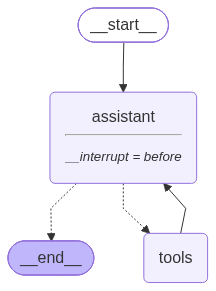

In [7]:
### WWorkflow with Langgraph
from IPython.display import Image, display

from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import MessagesState
from langgraph.graph import START, StateGraph
from langgraph.prebuilt import tools_condition, ToolNode
from langchain_core.messages import AIMessage,HumanMessage,SystemMessage

## system Message
sys_msg = SystemMessage(content="You are a helpful assistant tasked with performing arithmetic on a set of inputs.")

## node definition
def assistant(state:MessagesState):
    return {"messages":[llm_with_tools.invoke([sys_msg] + state["messages"])]}

#Graph
builder=StateGraph(MessagesState)

## Define nodes: 
builder.add_node("assistant",assistant)
builder.add_node("tools",ToolNode(tools))

## Define the Edges

builder.add_edge(START,"assistant")
builder.add_conditional_edges(
    "assistant",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition,

)
builder.add_edge("tools","assistant")

memory=MemorySaver()

### human in the loop
graph=builder.compile(interrupt_before=["assistant"],checkpointer=memory)

# Show
display(Image(graph.get_graph().draw_mermaid_png()))

In [8]:
thread={"configurable":{"thread_id":"123"}}
initial_input={"messages":HumanMessage(content="Multiply 2 and 3")}

In [9]:
for event in graph.stream(initial_input,thread,stream_mode="values"):
    event['messages'][-1].pretty_print()

================================ Human Message =================================

Multiply 2 and 3


In [10]:
state=graph.get_state(thread)
state.next

('assistant',)

In [11]:
graph.get_state_history(thread)

<generator object Pregel.get_state_history at 0x000001C6A04097A0>

In [12]:
state

StateSnapshot(values={'messages': [HumanMessage(content='Multiply 2 and 3', additional_kwargs={}, response_metadata={}, id='a66a9cdd-5db6-4336-9b75-5a1f88cbb9cd')]}, next=('assistant',), config={'configurable': {'thread_id': '123', 'checkpoint_ns': '', 'checkpoint_id': '1f19a333-f07b-6dba-8000-1454f4e6f809'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-08-17T12:00:31.667756+00:00', parent_config={'configurable': {'thread_id': '123', 'checkpoint_ns': '', 'checkpoint_id': '1f19a333-f076-6f9d-bfff-d00d55473d62'}}, tasks=(PregelTask(id='e0c3a37f-3136-1eb2-deba-9bd57ccc13b7', name='assistant', path=('__pregel_pull', 'assistant'), error=None, interrupts=(), state=None, result=None),), interrupts=())

![image.png](attachment:image.png)

In [13]:
## Continue the execution to Assistant
for event in graph.stream(None,thread,stream_mode="values"):
    event['messages'][-1].pretty_print()

================================ Human Message =================================

Multiply 2 and 3
================================== Ai Message ==================================
Tool Calls:
  multiply (call_54ec5013-0bd8-4713-8082-170368c77f43)
 Call ID: call_54ec5013-0bd8-4713-8082-170368c77f43
  Args:
    a: 2
    b: 3
================================= Tool Message =================================
Name: multiply

6


In [14]:
state=graph.get_state(thread)
state.next

('assistant',)

In [15]:
## Continue the execution of Assistant and then end
for event in graph.stream(None,thread,stream_mode="values"):
    event['messages'][-1].pretty_print()

================================= Tool Message =================================
Name: multiply

6
================================== Ai Message ==================================

The answer is 6.


### Edit Human Feedback

In [16]:
initial_input={"messages":HumanMessage(content="Multiply 2 and 3")}

thread={"configurable":{"thread_id":"1"}}
for event in graph.stream(initial_input,thread,stream_mode="values"):
    event['messages'][-1].pretty_print()

================================ Human Message =================================

Multiply 2 and 3


In [17]:

state=graph.get_state(thread)
state.next

('assistant',)

In [18]:
graph.update_state(thread,{"messages":[HumanMessage(content="No,please multiply 15 and 6")]})

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f19a337-3cab-6c6b-8001-a413876377a1'}}

In [19]:
new_state=graph.get_state(thread).values

for m in new_state['messages']:
    m.pretty_print()


================================ Human Message =================================

Multiply 2 and 3
================================ Human Message =================================

No,please multiply 15 and 6


In [20]:
for event in graph.stream(None, thread, stream_mode="values"):
    event['messages'][-1].pretty_print()

================================ Human Message =================================

No,please multiply 15 and 6
================================== Ai Message ==================================
Tool Calls:
  multiply (call_2f6c9bc9-ba92-486b-8330-56fcd329d9c1)
 Call ID: call_2f6c9bc9-ba92-486b-8330-56fcd329d9c1
  Args:
    a: 15
    b: 6
================================= Tool Message =================================
Name: multiply

90


In [21]:
for event in graph.stream(None, thread, stream_mode="values"):
    event['messages'][-1].pretty_print()

================================= Tool Message =================================
Name: multiply

90
================================== Ai Message ==================================

The answer is 90.


### Workflow will Wait for the User Input

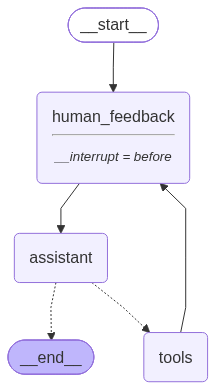

In [22]:
# System message
sys_msg = SystemMessage(content="You are a helpful assistant tasked with performing arithmetic on a set of inputs.")


## Human feedback node

def human_feedback(state:MessagesState):
    pass

### Assistant node
def assistant(state:MessagesState):
    return {"messages": [llm_with_tools.invoke([sys_msg] + state["messages"])]}

## Graph

# Graph
builder = StateGraph(MessagesState)

# Define nodes: these do the work
builder.add_node("assistant", assistant)
builder.add_node("tools", ToolNode(tools))
builder.add_node("human_feedback", human_feedback)


## Define the edges
builder.add_edge(START,"human_feedback")
builder.add_edge("human_feedback","assistant")
builder.add_conditional_edges(
    "assistant",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition,
)
builder.add_edge("tools","human_feedback")

memory=MemorySaver()
graph=builder.compile(interrupt_before=["human_feedback"],checkpointer=memory)

display(Image(graph.get_graph().draw_mermaid_png()))


In [24]:
# Input
initial_input = {"messages": "Multiply 2 and 3"}

# Thread
thread = {"configurable": {"thread_id": "5"}}

# Run the graph until the first interruption
for event in graph.stream(initial_input, thread, stream_mode="values"):
    event["messages"][-1].pretty_print()

## get user input

user_input=input("Tell me how you want to update the state:")
graph.update_state(thread,{"messages":user_input},as_node="human_feedback")

# Continue the graph execution
for event in graph.stream(None, thread, stream_mode="values"):
    event["messages"][-1].pretty_print()

================================ Human Message =================================

Multiply 2 and 3
================================ Human Message =================================

divide 12 by 3


BadRequestError: Error code: 400 - {'error_code': 'BAD_REQUEST', 'message': "Failed to render the request with the model's chat template: Conversation roles must alternate user/assistant/user/assistant/...\n"}

In [25]:
# Continue the graph execution
for event in graph.stream(None, thread, stream_mode="values"):
    event["messages"][-1].pretty_print()

================================ Human Message =================================

divide 12 by 3


BadRequestError: Error code: 400 - {'error_code': 'BAD_REQUEST', 'message': "Failed to render the request with the model's chat template: Conversation roles must alternate user/assistant/user/assistant/...\n"}